In [38]:
#Question 1 Tesla Stock Data
import yfinance as yf
import pandas as pd
tesla = yf.Ticker("TSLA")
tesla_history = tesla.history(period="max")
tesla_history.reset_index(inplace=True)
tesla_history.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


In [39]:
#Question 2 Tesla Revenue
import requests
import pandas as pd
from bs4 import BeautifulSoup
import re
#Webpage
url = "https://companiesmarketcap.com/tesla/revenue/"
html = requests.get(url).text
soup = BeautifulSoup(html, "html.parser")
#Extract data
text = soup.get_text(separator=" ", strip=True)
matches = re.findall(r"(\d{4})\s*\$([\d\.]+)\s*(Billion|Million)?", text)
#Dataframe conversion
data = []
for year, value, unit in matches:
    year = int(year)
    value = float(value)
    if unit == "Billion":
        revenue = value * 1e9
    elif unit == "Million":
        revenue = value * 1e6
    else:
        revenue = value * 1e9
    data.append([year, revenue])
tesla_revenue = pd.DataFrame(data, columns=["Year", "Revenue"])
tesla_revenue = tesla_revenue[(tesla_revenue["Year"] >= 2009) & (tesla_revenue["Year"] <= 2025)]
tesla_revenue = tesla_revenue.drop_duplicates("Year").sort_values("Year").reset_index(drop=True)
#Convert billions and show 2020 to 2024
tesla_revenue["Revenue (Billion USD)"] = (tesla_revenue["Revenue"] / 1e9).round(2).astype(str) + " B"
tesla_revenue = tesla_revenue[(tesla_revenue["Year"] >= 2020) & (tesla_revenue["Year"] <= 2025)]
#Display
tesla_revenue = tesla_revenue[["Year", "Revenue (Billion USD)"]]
print(tesla_revenue)


    Year Revenue (Billion USD)
11  2020               31.53 B
12  2021               53.82 B
13  2022               81.46 B
14  2023               96.77 B
15  2024               97.69 B


In [41]:
#Question 3 GameStop Stock Data
import yfinance as yf
import pandas as pd
gamestop = yf.Ticker("GME")
gamestop_history = gamestop.history(period="max")
gamestop_history.reset_index(inplace=True)
gamestop_history.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658002,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


In [42]:
#Question 4 GameStop Revenue
import requests
import pandas as pd
from bs4 import BeautifulSoup
import re
#Webpage
url = "https://companiesmarketcap.com/gamestop/revenue/"
html = requests.get(url).text
soup = BeautifulSoup(html, "html.parser")
#Extract data
text = soup.get_text(separator=" ", strip=True)
matches = re.findall(r"(\d{4})\s*\$([\d\.]+)\s*(Billion|Million)?", text)
#Dataframe conversion
data = []
for year, value, unit in matches:
    year = int(year)
    value = float(value)
    if unit == "Billion":
        revenue = value * 1e9
    elif unit == "Million":
        revenue = value * 1e6
    else:
        revenue = value * 1e9
    data.append([year, revenue])
gamestop_revenue = pd.DataFrame(data, columns=["Year", "Revenue"])
gamestop_revenue = gamestop_revenue[(gamestop_revenue["Year"] >= 2009) & (gamestop_revenue["Year"] <= 2025)]
gamestop_revenue = gamestop_revenue.drop_duplicates("Year").sort_values("Year").reset_index(drop=True)
#Convert billions and filter 2020–2024
gamestop_revenue["Revenue (Billion USD)"] = (gamestop_revenue["Revenue"] / 1e9).round(2).astype(str) + " B"
gamestop_revenue = gamestop_revenue[(gamestop_revenue["Year"] >= 2020) & (gamestop_revenue["Year"] <= 2025)]
#Display
gamestop_revenue = gamestop_revenue[["Year", "Revenue (Billion USD)"]]
print(gamestop_revenue)

    Year Revenue (Billion USD)
11  2020                5.08 B
12  2021                6.01 B
13  2022                5.92 B
14  2023                5.27 B
15  2024                3.82 B


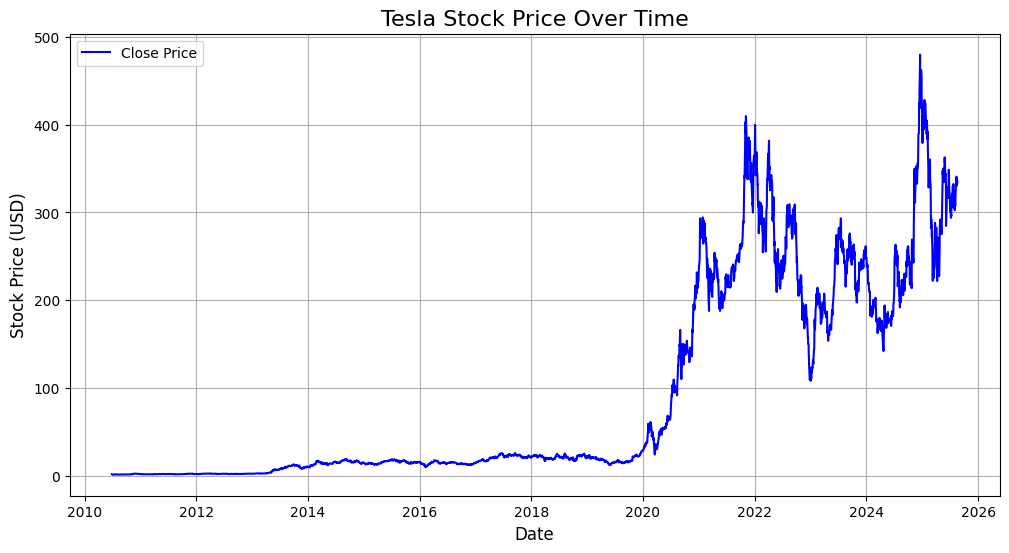

In [ ]:
#Question 5 Tesla Stock Graph
import matplotlib.pyplot as plt
def make_graph(df, title):
    plt.figure(figsize=(12,6))
    plt.plot(df['Date'], df['Close'], label="Close Price", color="blue")
    plt.title(title, fontsize=16)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Stock Price (USD)", fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.show()
make_graph(tesla_history, "Tesla Stock Price Over Time")

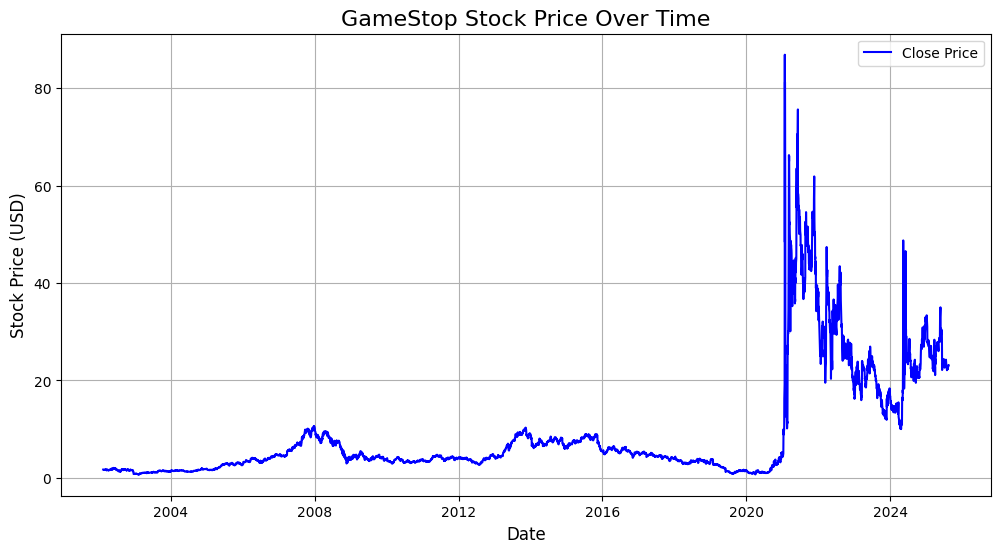

In [48]:
#Question 6 GameStop Stock Graph
import matplotlib.pyplot as plt
def make_graph(df, title):
    plt.figure(figsize=(12,6))
    plt.plot(df['Date'], df['Close'], label="Close Price", color="blue")
    plt.title(title, fontsize=16)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Stock Price (USD)", fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.show()
make_graph(gamestop_history, "GameStop Stock Price Over Time")